# Fine-Tune a Medical AI Model on Cancer Images with Python

**Model:**   
**Dataset:** NCT-CRC-HE — colorectal cancer tissue images: https://huggingface.co/datasets/1aurent/NCT-CRC-HE  
**Task:** Match tissue images with their class names using contrastive learning

---
![ChatGPT Image Apr 18, 2026, 06_48_16 PM.png](<attachment:ChatGPT Image Apr 18, 2026, 06_48_16 PM.png>)
### What you will learn
- How to load a vision-language model from Hugging Face
- How to preprocess medical images and text labels
- How to fine-tune with the  API
- How to evaluate and compare before vs. after fine-tuning

### The 9 tissue classes in this dataset

| Label | Tissue | Description |
|-------|--------|-------------|
| 0 | Adipose | Fat tissue; appears as empty white bubbles in H&E staining |
| 1 | Background | Empty slide area with no tissue present |
| 2 | Debris | Dead cells and tissue fragments; often seen in necrotic regions |
| 3 | Lymphocytes | Small immune cells; indicates inflammatory response near tumour |
| 4 | Mucus | Mucin-producing secretion; common in mucinous adenocarcinoma |
| 5 | Smooth Muscle | Muscle layer of the colon wall; helps distinguish invasion depth |
| 6 | Normal Colon Mucosa | Healthy glandular lining of the colon |
| 7 | Cancer-Associated Stroma | Connective tissue remodelled by the tumour microenvironment |
| 8 | Colorectal Adenocarcinoma Epithelium | Malignant glandular cells; the primary tumour tissue |
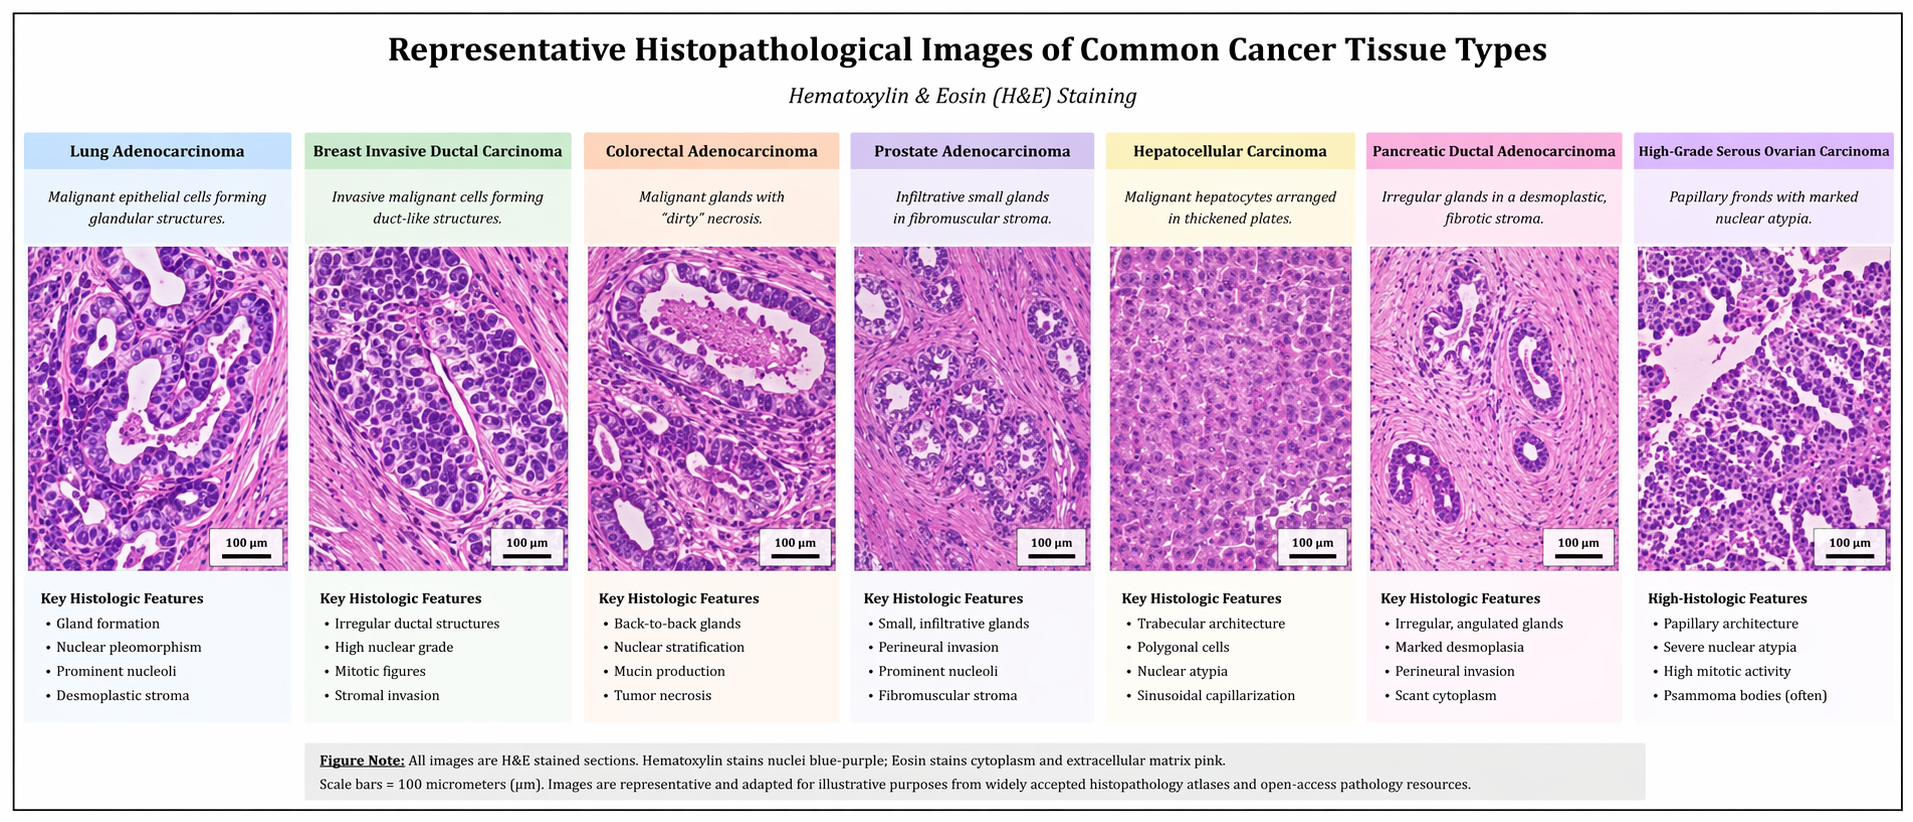

Classes: ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']

---
## Step 1 — Install required packages

In [1]:
# !pip install -q accelerate datasets evaluate transformers torchvision

---
## Step 2 — Load the model and processor

In [2]:
import torch
from transformers import AutoProcessor, AutoModel

model_id = "google/siglip-base-patch16-224"  # freely available, no approval needed

model = AutoModel.from_pretrained(model_id)
processor = AutoProcessor.from_pretrained(model_id)

print("Model loaded.")

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Model loaded.


---
## Step 3 — Load the dataset from Hugging Face

We load the **CRC_VAL_HE_7K** split directly from the `1aurent/NCT-CRC-HE` dataset on Hugging Face — no manual download needed.  
We split it into 6,000 training images and 1,000 validation images.

In [3]:
from datasets import load_dataset

# Load the 7K validation split directly from Hugging Face — no local files needed
data = load_dataset("1aurent/NCT-CRC-HE", split="CRC_VAL_HE_7K")

data = data.train_test_split(train_size=6000, test_size=1000, shuffle=True, seed=42)
data["validation"] = data.pop("test")

raw_val = data["validation"]  # save raw PIL images before preprocessing removes them

print(data)

c:\Users\laxmi\anaconda3\envs\ml\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (7.1.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 6000
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 1000
    })
})


---
## Step 4 — Preprocess images and text

In [5]:
from torchvision.transforms import Compose, Resize, ToTensor, Normalize, InterpolationMode

# Class names come directly from the dataset — no hardcoding needed
TISSUE_CLASSES = data["train"].features["label"].names
print("Classes:", TISSUE_CLASSES)

mean = processor.image_processor.image_mean
std  = processor.image_processor.image_std
size = 224  # SigLIP base-patch16-224 always uses 224x224

image_transform = Compose([
    Resize((size, size), interpolation=InterpolationMode.BILINEAR),
    ToTensor(),
    Normalize(mean=mean, std=std),
])


def preprocess(examples):
    pixel_values = [image_transform(img.convert("RGB")) for img in examples["image"]]
    captions     = [TISSUE_CLASSES[label] for label in examples["label"]]
    tokens = processor.tokenizer(
        captions,
        max_length=64,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
    )
    tokens["pixel_values"] = pixel_values
    return tokens


data = data.map(preprocess, batched=True, remove_columns=["image", "label"])
data.set_format(type="torch", columns=["pixel_values", "input_ids", "attention_mask"])
print("Preprocessing done.")

Classes: ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']
Preprocessing done.


---
## Step 5 — Define a data collator

In [6]:
import torch


def collate_fn(examples):
    return {
        "pixel_values":   torch.stack([ex["pixel_values"]   for ex in examples]),
        "input_ids":      torch.stack([ex["input_ids"]      for ex in examples]),
        "attention_mask": torch.stack([ex["attention_mask"] for ex in examples]),
        "return_loss":    True,
    }

---
## Step 6 — Configure training

In [7]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="siglip-base-finetuned-crc",
    num_train_epochs=5,
    per_device_train_batch_size=128,
    learning_rate=1e-4,
    warmup_steps=50,
    lr_scheduler_type="cosine",
    logging_steps=20,
    save_strategy="epoch",
    eval_strategy="steps",
    eval_steps=50,
    fp16=torch.cuda.is_available(),
)

---
## Step 7 — Train the model

In [8]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=data["train"],
    eval_dataset=data["validation"].shuffle().select(range(200)),
    data_collator=collate_fn,
)

trainer.train()

Step,Training Loss,Validation Loss
50,4.658444,2.538307
100,4.123793,2.881082
150,3.926706,2.856865
200,3.809789,2.819878
235,3.806388,2.876365


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=235, training_loss=4.45532237925428, metrics={'train_runtime': 284.2247, 'train_samples_per_second': 105.55, 'train_steps_per_second': 0.827, 'total_flos': 2054940940800000.0, 'train_loss': 4.45532237925428, 'epoch': 5.0})

---
## Step 8 — Save the model

In [9]:
trainer.save_model()
print("Model saved to:", training_args.output_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: siglip-base-finetuned-crc


---
## Step 9 — Compare: before vs after fine-tuning

In [10]:
import evaluate

device = "cuda" if torch.cuda.is_available() else "cpu"

test_images = raw_val["image"]
true_labels = raw_val["label"]

accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")


def predict(mdl, images, batch_size=32):
    mdl.eval().to(device)
    all_preds = []
    for i in range(0, len(images), batch_size):
        batch = images[i : i + batch_size]
        inputs = processor(
            text=TISSUE_CLASSES,
            images=batch,
            padding="max_length",
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = mdl(**inputs)

        all_preds.extend(outputs.logits_per_image.argmax(dim=1).tolist())
    return all_preds


def score(preds):
    acc = accuracy_metric.compute(predictions=preds, references=true_labels)["accuracy"]
    f1  = f1_metric.compute(predictions=preds, references=true_labels, average="weighted")["f1"]
    return acc, f1

In [11]:
# Original pretrained model — no fine-tuning
pt_model = AutoModel.from_pretrained(model_id)
pt_preds = predict(pt_model, test_images)
pt_acc, pt_f1 = score(pt_preds)
print(f"Before fine-tuning — Accuracy: {pt_acc:.1%}  |  F1: {pt_f1:.3f}")

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Before fine-tuning — Accuracy: 14.5%  |  F1: 0.052


In [12]:
# Our fine-tuned model
ft_model = AutoModel.from_pretrained(training_args.output_dir)
ft_preds = predict(ft_model, test_images)
ft_acc, ft_f1 = score(ft_preds)
print(f"After  fine-tuning — Accuracy: {ft_acc:.1%}  |  F1: {ft_f1:.3f}")

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

After  fine-tuning — Accuracy: 95.2%  |  F1: 0.944


In [ ]:
# from huggingface_hub import login
# login()  # paste your HF token here
# trainer.push_to_hub()

---
## What's next?

- Train for more epochs and watch accuracy improve further
- Use the full 100K dataset instead of 9K
- Push your model to Hugging Face Hub:
  ```python
  from huggingface_hub import login
  login()  # paste your HF token here
  trainer.push_to_hub()
  ```
- Try a larger model: `google/siglip-so400m-patch14-384`

**If this video helped you, like and subscribe — it really helps the channel!**